# NLP Masterclass – Análisis de Planes de Gobierno
## TF-IDF, Word2Vec, Topic Modeling, Similaridad Semántica y Clustering

**Curso:** Machine Learning  
**Autor del curso:** Josef Rodriguez

---

## Introducción

En este notebook construiremos una **Masterclass completa de Procesamiento de Lenguaje Natural (NLP)** usando un dataset real de **planes de gobierno** de candidatos presidenciales.

La idea no es solo aplicar código, sino **entender cada concepto**, su lógica, sus ventajas, sus limitaciones y cómo se integra dentro de un pipeline profesional de análisis de texto.

Trabajaremos con un dataset en español almacenado en el repositorio del curso:

`https://raw.githubusercontent.com/josefrodrim/ML-course/main/data/planes_gobierno_texto.csv`

---

## Objetivos de aprendizaje

Al finalizar este notebook serás capaz de:

- entender qué es NLP y por qué es importante
- limpiar y preparar texto en español
- representar documentos con **TF-IDF**
- aprender embeddings con **Word2Vec**
- construir embeddings de documentos
- comparar candidatos mediante **similaridad del coseno**
- visualizar estructuras semánticas con **PCA** y **t-SNE**
- descubrir temas latentes con **LDA (Topic Modeling)**
- generar **WordClouds**
- aplicar **clustering con K-Means**
- interpretar resultados de manera crítica

---

## Pipeline que construiremos

Texto → Limpieza → Tokenización → EDA → TF-IDF → Word2Vec → Embeddings de documentos → Similaridad → PCA / t-SNE → LDA → Clustering

---

## ¿Por qué este dataset es potente?

Porque permite trabajar con:

- **texto real**
- **español**
- **política y discurso público**
- **documentos largos**
- **comparación semántica entre actores**

Esto hace que la clase sea más cercana a proyectos reales de NLP que un dataset pequeño de juguete.


# 1. Librerías

Usaremos varias librerías especializadas:

- **pandas**: manipulación tabular
- **numpy**: operaciones numéricas
- **matplotlib** y **seaborn**: visualización
- **scikit-learn**: TF-IDF, PCA, t-SNE, K-Means, similitud del coseno
- **gensim**: Word2Vec y LDA
- **wordcloud**: nubes de palabras
- **collections.Counter**: conteo de tokens

> Si alguna librería no está instalada, puedes usar `pip install nombre_libreria`.


In [1]:
import pandas as pd
import numpy as np
import re
from collections import Counter

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.decomposition import PCA, LatentDirichletAllocation
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from sklearn.metrics.pairwise import cosine_similarity

from gensim.models import Word2Vec
from wordcloud import WordCloud

sns.set_theme()
pd.set_option("display.max_colwidth", 200)


# 2. Carga del dataset desde GitHub

El dataset contiene dos columnas principales:

- **presidente**: nombre del candidato
- **texto_plan**: texto completo del plan de gobierno

Cada fila representa un documento.


In [2]:
url = "https://raw.githubusercontent.com/josefrodrim/ML-course/main/data/planes_gobierno_texto.csv"

df = pd.read_csv(url)

df.head()


,presidente,texto_plan
0,PABLO ALFONSO LOPEZ CHAU NAVA,formato del resumen del plan de gobierno el formato resumen de plan de gobierno tiene como objetivo brindar al ciudadano una visión resumida del plan de gobierno presentado por las organizaciones ...
1,RONALD DARWIN ATENCIO SOTOMAYOR,formato del resumen del plan de gobierno el formato resumen de plan de gobierno tiene como objetivo brindar al ciudadano una visión resumida del plan de gobierno presentado por las organizaciones ...
2,CESAR ACUÑA PERALTA,formato del resumen del plan de gobierno el formato resumen de plan de gobierno tiene como objetivo brindar al ciudadano una visión resumida del plan de gobierno presentado por las organizaciones ...
3,JOSE DANIEL WILLIAMS ZAPATA,formato del resumen del plan de gobierno el formato resumen de plan de gobierno tiene como objetivo brindar al ciudadano una visión resumida del plan de gobierno presentado por las organizaciones ...
4,ALVARO GONZALO PAZ DE LA BARRA FREIGEIRO,formato del resumen del plan de gobierno el formato resumen de plan de gobierno tiene como objetivo brindar al ciudadano una visión resumida del plan de gobierno presentado por las organizaciones ...


# 3. Exploración inicial del dataset

Antes de modelar, siempre conviene entender la estructura del dato.

Preguntas básicas:

- ¿cuántos documentos tenemos?
- ¿hay valores nulos?
- ¿qué tan largos son los documentos?
- ¿todos los documentos parecen válidos?


In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 35 entries, 0 to 34
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   presidente  35 non-null     str  
 1   texto_plan  35 non-null     str  
dtypes: str(2)
memory usage: 692.0 bytes


In [4]:
print("Número de candidatos:", len(df))
print("Nulos por columna:")
print(df.isna().sum())


Número de candidatos: 35
Nulos por columna:
presidente    0
texto_plan    0
dtype: int64


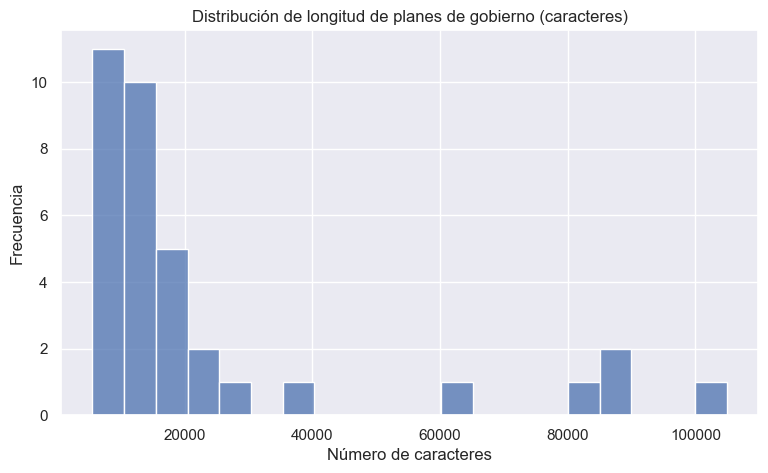

In [5]:
df["longitud_caracteres"] = df["texto_plan"].fillna("").str.len()

plt.figure(figsize=(9, 5))
sns.histplot(df["longitud_caracteres"], bins=20)
plt.title("Distribución de longitud de planes de gobierno (caracteres)")
plt.xlabel("Número de caracteres")
plt.ylabel("Frecuencia")
plt.show()


## Interpretación

La longitud de los documentos importa porque en NLP los planes muy cortos y muy largos pueden afectar:

- la densidad de términos
- la calidad del embedding promedio
- la comparación entre candidatos
- la inferencia de temas

En problemas reales, siempre conviene revisar este aspecto.


# 4. Limpieza de texto

## ¿Qué es la limpieza de texto?

La limpieza de texto es el proceso de transformar documentos crudos en una versión más consistente para análisis computacional.

En este notebook haremos una limpieza **conservadora**, porque queremos mantener la mayor parte del contenido semántico.

### Pasos

- convertir a minúsculas
- eliminar saltos de línea
- eliminar caracteres especiales y números
- normalizar espacios

> En una versión más avanzada podríamos agregar lematización, stemming o stopwords personalizadas.


In [6]:
def limpiar_texto(texto: str) -> str:
    texto = str(texto).lower()
    texto = re.sub(r"\n", " ", texto)
    texto = re.sub(r"[^a-záéíóúñü ]", " ", texto)
    texto = re.sub(r"\s+", " ", texto).strip()
    return texto

df["texto_clean"] = df["texto_plan"].apply(limpiar_texto)

df[["presidente", "texto_clean"]].head(2)


,presidente,texto_clean
0,PABLO ALFONSO LOPEZ CHAU NAVA,formato del resumen del plan de gobierno el formato resumen de plan de gobierno tiene como objetivo brindar al ciudadano una visión resumida del plan de gobierno presentado por las organizaciones ...
1,RONALD DARWIN ATENCIO SOTOMAYOR,formato del resumen del plan de gobierno el formato resumen de plan de gobierno tiene como objetivo brindar al ciudadano una visión resumida del plan de gobierno presentado por las organizaciones ...


# 5. Tokenización

## ¿Qué es un token?

Un **token** es una unidad mínima de análisis textual. En muchos problemas de NLP clásico, un token es una palabra.

Ejemplo:

`"la economía crecerá este año"` → `["la", "economía", "crecerá", "este", "año"]`

La tokenización es fundamental porque muchos algoritmos operan sobre listas de palabras y no sobre cadenas completas.


In [7]:
df["tokens"] = df["texto_clean"].str.split()

df["num_palabras"] = df["tokens"].apply(len)

df[["presidente", "num_palabras"]].head()


,presidente,num_palabras
0,PABLO ALFONSO LOPEZ CHAU NAVA,14194
1,RONALD DARWIN ATENCIO SOTOMAYOR,3699
2,CESAR ACUÑA PERALTA,763
3,JOSE DANIEL WILLIAMS ZAPATA,1564
4,ALVARO GONZALO PAZ DE LA BARRA FREIGEIRO,792


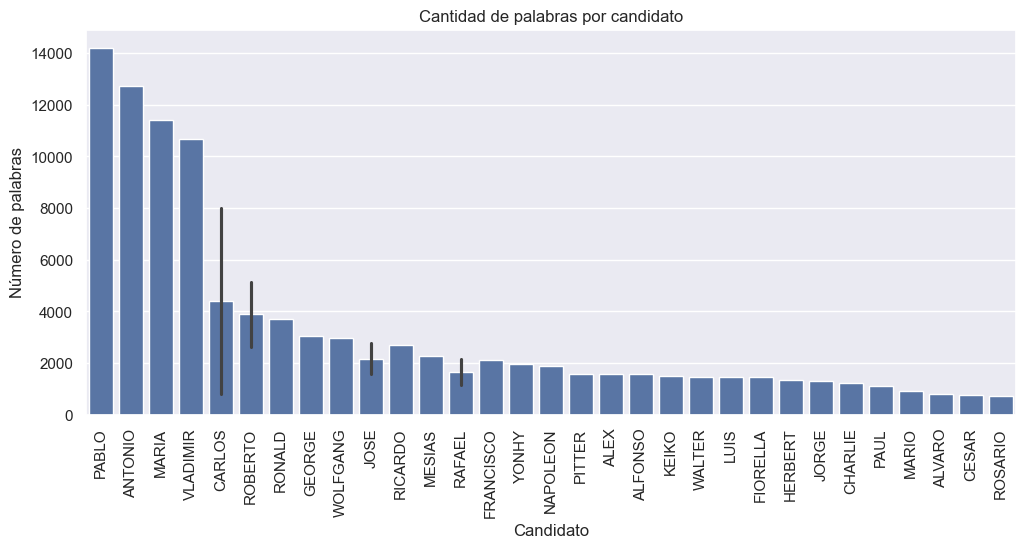

In [8]:
plt.figure(figsize=(12, 5))
sns.barplot(
    data=df.sort_values("num_palabras", ascending=False),
    x=df.sort_values("num_palabras", ascending=False)["presidente"].str.split().str[0],
    y="num_palabras"
)
plt.xticks(rotation=90)
plt.title("Cantidad de palabras por candidato")
plt.xlabel("Candidato")
plt.ylabel("Número de palabras")
plt.show()


# 6. Exploración léxica básica

Antes de pasar a modelos más complejos, conviene mirar las palabras más frecuentes.

Esto ayuda a detectar:

- ruido
- palabras dominantes
- vocabulario político recurrente
- necesidad de limpiar más el corpus


In [9]:
all_tokens = [token for doc in df["tokens"] for token in doc]
frecuencias = Counter(all_tokens)

top_20 = pd.DataFrame(frecuencias.most_common(20), columns=["palabra", "frecuencia"])
top_20


,palabra,frecuencia
0,de,10825
1,y,5533
2,la,4483
3,en,3137
4,el,2381
5,del,2130
6,a,1764
7,con,1667
8,los,1238
9,que,1189


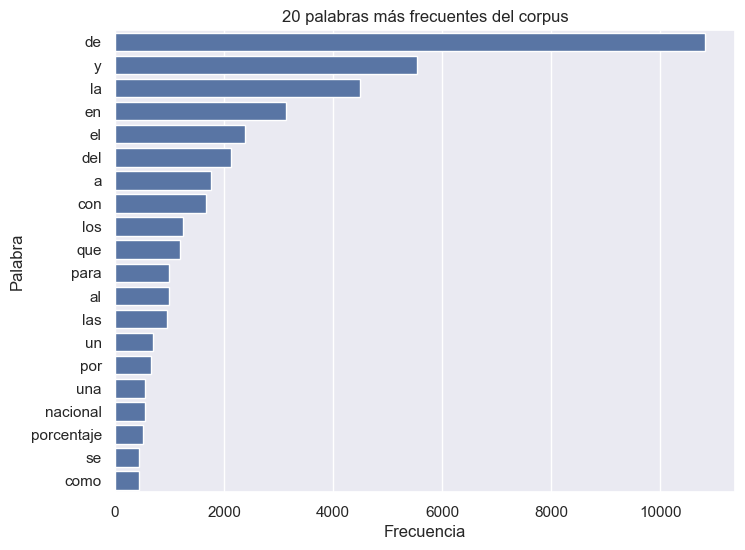

In [10]:
plt.figure(figsize=(8, 6))
sns.barplot(data=top_20, x="frecuencia", y="palabra")
plt.title("20 palabras más frecuentes del corpus")
plt.xlabel("Frecuencia")
plt.ylabel("Palabra")
plt.show()


# 7. WordCloud general del corpus

## ¿Qué es una WordCloud?

Una **nube de palabras** es una visualización donde el tamaño de cada palabra depende de su frecuencia o peso.

No reemplaza análisis cuantitativo, pero es útil como exploración inicial o recurso pedagógico.


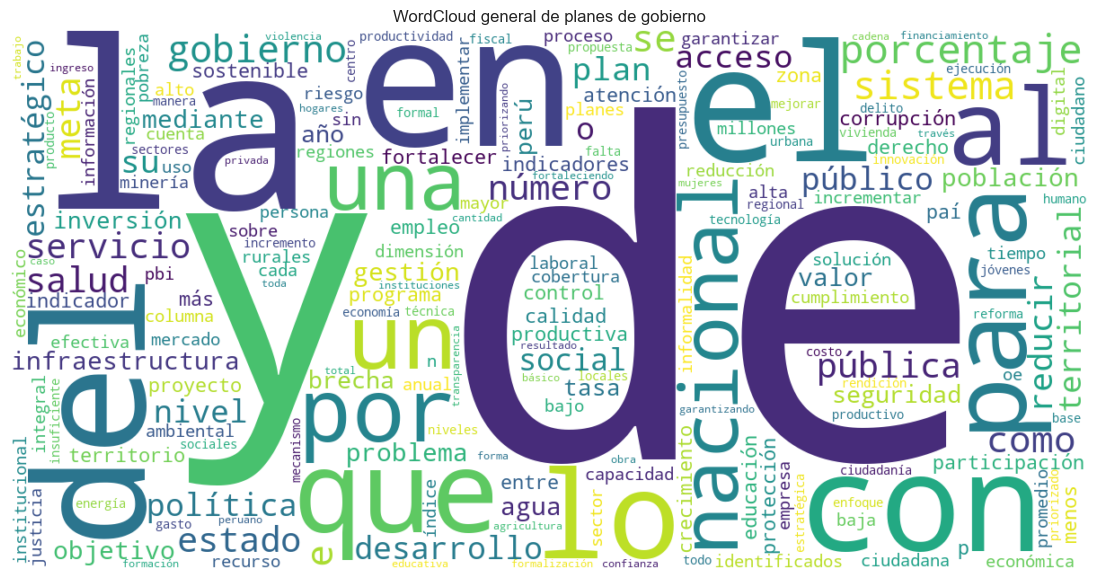

In [11]:
texto_total = " ".join(df["texto_clean"])

wc = WordCloud(
    width=1200,
    height=600,
    background_color="white",
    collocations=False
).generate(texto_total)

plt.figure(figsize=(14, 7))
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.title("WordCloud general de planes de gobierno")
plt.show()


# 8. TF-IDF

## Definición

**TF-IDF (Term Frequency – Inverse Document Frequency)** es una técnica clásica de representación de texto utilizada en Procesamiento de Lenguaje Natural (NLP).

Su objetivo es medir **qué tan importante es una palabra dentro de un documento**, considerando también **qué tan común es esa palabra en todo el corpus**.

---

## Intuición

La lógica detrás de TF-IDF es simple:

- Si una palabra aparece **muchas veces en un documento**, probablemente sea importante para ese documento.
- Pero si esa palabra aparece **en casi todos los documentos**, entonces **no ayuda a diferenciar documentos**.

TF-IDF equilibra estas dos ideas.



# Componentes de TF-IDF

## 1. Term Frequency (TF)

La **frecuencia de término** mide cuántas veces aparece un término en un documento.

$$
TF(t,d) = \frac{f_{t,d}}{\sum_{t' \in d} f_{t',d}}
$$

donde:

- $t$ = término (palabra)
- $d$ = documento
- $f_{t,d}$ = número de veces que el término $t$ aparece en el documento $d$
- $\sum_{t' \in d} f_{t',d}$ = número total de palabras en el documento $d$



## 2. Inverse Document Frequency (IDF)

El **IDF** mide qué tan rara es una palabra en todo el corpus.

$$
IDF(t) = \log \left(\frac{N}{df_t}\right)
$$

donde:

- $N$ = número total de documentos en el corpus
- $df_t$ = número de documentos que contienen el término $t$

Interpretación:

- Si una palabra aparece en **muchos documentos**, su IDF será **bajo**.
- Si aparece en **pocos documentos**, su IDF será **alto**.


## 3. TF-IDF final

El peso final de un término en un documento es:

$$
TFIDF(t,d) = TF(t,d) \times IDF(t)
$$

Esto significa que una palabra tendrá un peso alto si:

- aparece frecuentemente en un documento
- pero aparece en pocos documentos del corpus.


## Interpretación práctica

- Palabras muy comunes como **"el", "la", "de"** tendrán TF alto pero **IDF muy bajo**.
- Palabras específicas como **"infraestructura", "tributación", "exportaciones"** pueden tener **TF-IDF alto** si aparecen en pocos documentos.

Por eso TF-IDF es muy útil para:

- clasificación de texto
- búsqueda de información
- clustering de documentos
- análisis de contenido


In [12]:
import nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/josefrodriguez/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [13]:
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer

# stopwords en español
spanish_stopwords = stopwords.words("spanish")

vectorizer = TfidfVectorizer(
    max_features=3000,
    stop_words=spanish_stopwords
)

X_tfidf = vectorizer.fit_transform(df["texto_clean"])

print("Shape TF-IDF:", X_tfidf.shape)


Shape TF-IDF: (35, 3000)


## Nota importante

`scikit-learn` no incluye por defecto una lista robusta de stopwords en español para todos los casos.

En una clase avanzada puedes:

- usar `nltk.corpus.stopwords`
- construir una lista propia
- combinar stopwords genéricas con stopwords de dominio político

En esta notebook mantenemos una versión simple para favorecer reproducibilidad.


In [14]:
feature_names = vectorizer.get_feature_names_out()
scores = np.asarray(X_tfidf.mean(axis=0)).flatten()

top_idx = scores.argsort()[-25:]
top_terms = pd.DataFrame({
    "palabra": [feature_names[i] for i in top_idx],
    "score_tfidf": scores[top_idx]
}).sort_values("score_tfidf", ascending=False)

top_terms.head(15)


,palabra,score_tfidf
24,porcentaje,0.094904
23,nacional,0.088635
22,gobierno,0.081920
21,plan,0.080047
20,sistema,0.067371
19,reducir,0.065601
18,número,0.058880
17,salud,0.055956
16,mediante,0.049080
15,nivel,0.048602


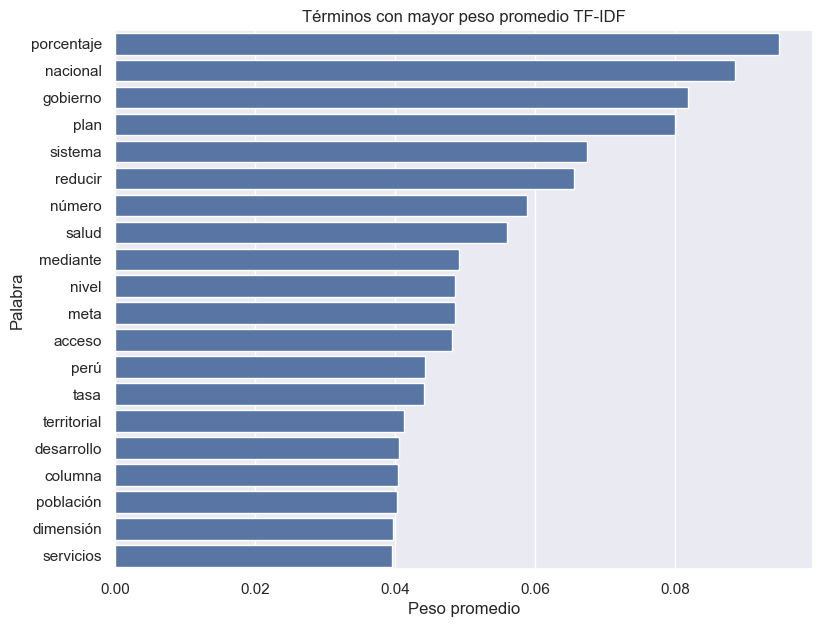

In [15]:
plt.figure(figsize=(9, 7))
sns.barplot(data=top_terms.head(20), x="score_tfidf", y="palabra")
plt.title("Términos con mayor peso promedio TF-IDF")
plt.xlabel("Peso promedio")
plt.ylabel("Palabra")
plt.show()


# 9. TF-IDF por candidato

También podemos identificar las palabras más representativas de un candidato específico.

Esto es útil para responder preguntas como:

- ¿qué temas enfatiza más un candidato?
- ¿qué vocabulario lo diferencia?


In [16]:
def top_tfidf_terms_for_doc(doc_index, top_n=15):
    row = X_tfidf[doc_index].toarray().flatten()
    idx = row.argsort()[-top_n:][::-1]
    return pd.DataFrame({
        "palabra": [feature_names[i] for i in idx],
        "score_tfidf": row[idx]
    })

for i in range(len(df)):
    
    candidato = df.loc[i, "presidente"]
    
    print("\n===============================")
    print("Candidato:", candidato)
    
    display(top_tfidf_terms_for_doc(i, top_n=15))



Candidato: PABLO ALFONSO LOPEZ CHAU NAVA


,palabra,score_tfidf
0,porcentaje,0.198604
1,sistema,0.137336
2,acceso,0.126257
3,servicios,0.112740
4,desarrollo,0.111032
5,gestión,0.108940
6,cooperativas,0.105510
7,sostenible,0.104142
8,productiva,0.103994
9,asociatividad,0.102820



Candidato: RONALD DARWIN ATENCIO SOTOMAYOR


,palabra,score_tfidf
0,estratégica,0.437457
1,actividad,0.348359
2,salud,0.274160
3,diresa,0.203272
4,geresa,0.203272
5,regionales,0.132726
6,estratégico,0.131154
7,porcentaje,0.109483
8,ley,0.109005
9,derecho,0.105318



Candidato: CESAR ACUÑA PERALTA


...

,palabra,score_tfidf
0,menos,0.177652
1,nacional,0.157048
2,según,0.156273
3,salud,0.127358
4,nivel,0.115411
5,niños,0.107859
6,fortalecer,0.106793
7,servicios,0.105794
8,residuos,0.099699
9,reducir,0.098899



Candidato: ROSARIO DEL PILAR FERNANDEZ BAZAN


,palabra,score_tfidf
0,plan,0.204603
1,gobierno,0.198997
2,reducción,0.161350
3,preventiva,0.158289
4,fortalecer,0.152503
5,progresiva,0.151300
6,administrativo,0.141387
7,médica,0.131519
8,pasivos,0.131519
9,empleo,0.117225



Candidato: ROBERTO ENRIQUE CHIABRA LEON


,palabra,score_tfidf
0,minerí,0.245364
1,economí,0.218101
2,pu,0.190839
3,polí,0.190839
4,paí,0.190839
5,educacio,0.163576
6,tra,0.136313
7,lares,0.136313
8,poblacio,0.136313
9,millones,0.124320


# 10. Word2Vec

## Definición

**Word2Vec** es un modelo de aprendizaje no supervisado que aprende **embeddings de palabras**, es decir, vectores densos que capturan relaciones semánticas.

La idea central es:

> Palabras que aparecen en contextos similares tendrán vectores similares.

### ¿Por qué es importante?

A diferencia de TF-IDF, Word2Vec no solo mide importancia de términos; también intenta aprender **significado distribuido**.

### Arquitecturas principales

- **CBOW**: predice la palabra central a partir del contexto
- **Skip-Gram**: predice el contexto a partir de la palabra central

En `gensim`:

- `sg=0` → CBOW
- `sg=1` → Skip-Gram


In [17]:
sentences = df["tokens"].tolist()

w2v = Word2Vec(
    sentences=sentences,
    vector_size=100,
    window=10,
    min_count=5,
    sg=1,
    workers=4,
    seed=42
)

print("Tamaño del vocabulario Word2Vec:", len(w2v.wv))


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


Tamaño del vocabulario Word2Vec: 2413


## Parámetros clave

- **vector_size**: dimensión del embedding
- **window**: tamaño del contexto
- **min_count**: frecuencia mínima para incluir una palabra
- **sg=1**: usa Skip-Gram, útil para capturar mejor palabras menos frecuentes


In [41]:
palabras_consulta = ["economia", "salud", "educación", "seguridad", "corrupcion", "empleo", "pobreza", "medioambiente", "minería"]

for palabra in palabras_consulta:
    if palabra in w2v.wv:
        print(f"\nPalabras similares a '{palabra}':")
        print(w2v.wv.most_similar(palabra, topn=8))
    else:
        print(f"'{palabra}' no está en el vocabulario.")


'economia' no está en el vocabulario.

Palabras similares a 'salud':
[('atención', 0.8956969976425171), ('mental', 0.853035032749176), ('establecimientos', 0.8426283001899719), ('medicamentos', 0.8419047594070435), ('minsa', 0.8366579413414001), ('único', 0.8323286175727844), ('atenciones', 0.8209578394889832), ('hospitales', 0.8185547590255737)]

Palabras similares a 'educación':
[('estudiantes', 0.9161409735679626), ('conclusión', 0.8903874754905701), ('superior', 0.8878442049026489), ('básica', 0.886233925819397), ('educativo', 0.8613017797470093), ('educativas', 0.8341025114059448), ('docentes', 0.828383207321167), ('egresados', 0.8281811475753784)]

Palabras similares a 'seguridad':
[('jurídica', 0.7923411130905151), ('delictiva', 0.7709096074104309), ('criminalidad', 0.7609916925430298), ('cotidiana', 0.7546066045761108), ('ciudadana', 0.7471286058425903), ('medios', 0.7432366013526917), ('delito', 0.7406913042068481), ('juzgados', 0.7371042370796204)]
'corrupcion' no está en el 

# 11. Visualización de embeddings de palabras con PCA

Los embeddings tienen 100 dimensiones. Para visualizarlos, reducimos a 2 dimensiones.

## ¿Qué hace PCA?

**PCA (Principal Component Analysis)** proyecta los datos en nuevas dimensiones que explican la mayor parte de la varianza.

Es útil para tener una visión global, aunque no siempre separa bien grupos semánticos finos.


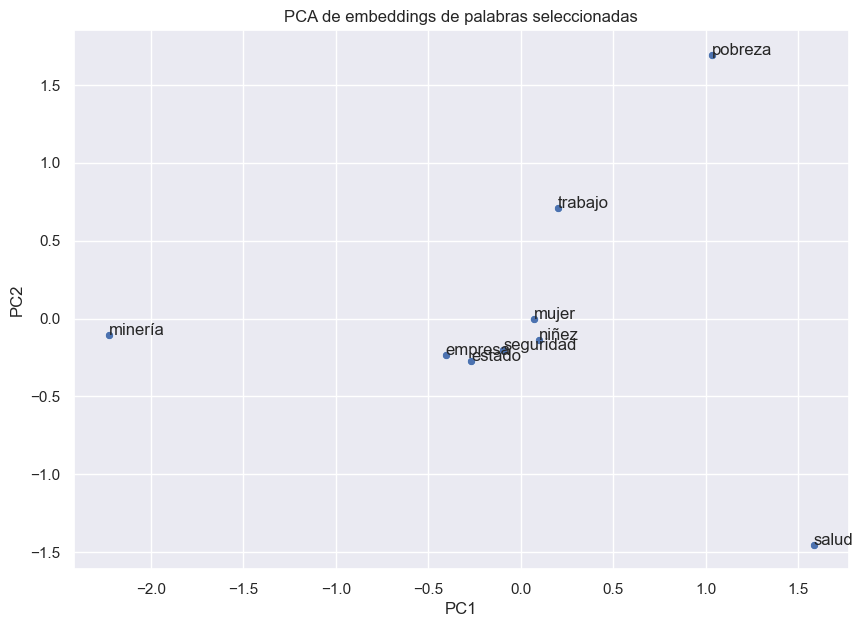

In [42]:
selected_words = [w for w in ["economia", "salud", "educacion", "seguridad", "trabajo", "pobreza",
                              "inversion", "corrupcion", "estado", "empresa", "mujer", "niñez", "minería"] if w in w2v.wv]

word_vectors = np.array([w2v.wv[w] for w in selected_words])

pca_words = PCA(n_components=2, random_state=42)
coords_words_pca = pca_words.fit_transform(word_vectors)

plt.figure(figsize=(10, 7))
sns.scatterplot(x=coords_words_pca[:, 0], y=coords_words_pca[:, 1])

for i, w in enumerate(selected_words):
    plt.text(coords_words_pca[i, 0], coords_words_pca[i, 1], w)

plt.title("PCA de embeddings de palabras seleccionadas")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()


# 12. Embeddings de documentos

## Problema

Word2Vec produce vectores para **palabras**, no para documentos completos.

## Solución simple

Una forma clásica de representar un documento es **promediar los embeddings de sus palabras**.

No es la técnica más sofisticada, pero es útil, interpretable y muy buena para enseñar.


In [43]:
def doc_embedding(tokens, model, dim=100):
    vecs = [model.wv[w] for w in tokens if w in model.wv]
    if len(vecs) == 0:
        return np.zeros(dim)
    return np.mean(vecs, axis=0)

doc_vectors = np.vstack(df["tokens"].apply(lambda x: doc_embedding(x, w2v, dim=100)))

doc_vectors.shape


(35, 100)

# 13. Similaridad entre candidatos

## Similaridad del coseno

La **similaridad del coseno** mide la similitud entre dos vectores calculando el coseno del ángulo entre ellos en un espacio vectorial.

Esta métrica es ampliamente utilizada en **NLP, recuperación de información y sistemas de recomendación**, porque compara **direcciones de vectores** y no su magnitud.



## Fórmula

$$
\text{cosine}(A,B) =
\frac{A \cdot B}{\lVert A \rVert \, \lVert B \rVert}
$$

donde:

- $A$ = vector del documento (por ejemplo, el embedding de un plan de gobierno)
- $B$ = vector de otro documento
- $A \cdot B$ = producto punto entre los vectores
- $\lVert A \rVert$ = norma euclidiana del vector $A$
- $\lVert B \rVert$ = norma euclidiana del vector $B$



## Expansión del producto punto

Si los vectores tienen dimensión $n$, entonces:

$$
A \cdot B = \sum_{i=1}^{n} A_i B_i
$$

y las normas se definen como:

$$
\lVert A \rVert =
\sqrt{\sum_{i=1}^{n} A_i^2}
$$

$$
\lVert B \rVert =
\sqrt{\sum_{i=1}^{n} B_i^2}
$$



## Interpretación

El valor de la similaridad del coseno se encuentra en el rango:

$$
-1 \leq \text{cosine}(A,B) \leq 1
$$

Interpretación práctica:

- **1** → documentos prácticamente idénticos en términos semánticos  
- **0** → documentos sin relación semántica clara  
- **-1** → direcciones opuestas (poco común en embeddings promedio de texto)


## Intuición geométrica

En NLP no nos interesa tanto la **magnitud del vector**, sino su **dirección en el espacio semántico**.

Por eso la similaridad del coseno es preferida frente a la distancia euclidiana en muchos problemas de análisis de texto.


In [21]:
sim_matrix = cosine_similarity(doc_vectors)

sim_df = pd.DataFrame(sim_matrix, index=df["presidente"], columns=df["presidente"])
sim_df.iloc[:32, :32]


presidente,PABLO ALFONSO LOPEZ CHAU NAVA,RONALD DARWIN ATENCIO SOTOMAYOR,CESAR ACUÑA PERALTA,JOSE DANIEL WILLIAMS ZAPATA,ALVARO GONZALO PAZ DE LA BARRA FREIGEIRO,KEIKO SOFIA FUJIMORI HIGUCHI,FIORELLA GIANNINA MOLINELLI ARISTONDO,ROBERTO HELBERT SANCHEZ PALOMINO,RAFAEL JORGE BELAUNDE LLOSA,PITTER ENRIQUE VALDERRAMA PEÑA,...,VLADIMIR ROY CERRON ROJAS,FRANCISCO ERNESTO DIEZ-CANSECO TÁVARA,MARIO ENRIQUE VIZCARRA CORNEJO,WALTER GILMER CHIRINOS PURIZAGA,ALFONSO CARLOS ESPA Y GARCES-ALVEAR,CARLOS ERNESTO JAICO CARRANZA,JOSE LEON LUNA GALVEZ,MARIA SOLEDAD PEREZ TELLO DE RODRIGUEZ,PAUL DAVIS JAIMES BLANCO,RAFAEL BERNARDO LÓPEZ ALIAGA CAZORLA
presidente,,,,,,,,,,,,,,,,,,,,,
PABLO ALFONSO LOPEZ CHAU NAVA,1.000000,0.978484,0.939428,0.974110,0.961221,0.982022,0.978760,0.990108,0.964621,0.979760,...,0.987477,0.968448,0.962931,0.967186,0.975903,0.948697,0.987972,0.979555,0.968129,0.962834
RONALD DARWIN ATENCIO SOTOMAYOR,0.978484,1.000000,0.966879,0.994345,0.986877,0.990607,0.987573,0.988412,0.990542,0.991232,...,0.986679,0.984617,0.984105,0.985966,0.990140,0.979579,0.990266,0.979579,0.985177,0.987736
CESAR ACUÑA PERALTA,0.939428,0.966879,1.000000,0.972274,0.975713,0.974530,0.967899,0.964020,0.974011,0.976784,...,0.944409,0.979050,0.976746,0.973312,0.978180,0.982145,0.964741,0.961081,0.972918,0.980978
JOSE DANIEL WILLIAMS ZAPATA,0.974110,0.994345,0.972274,1.000000,0.992973,0.994557,0.988470,0.989516,0.995783,0.994040,...,0.983357,0.992459,0.988576,0.993535,0.994258,0.987577,0.992694,0.984972,0.994030,0.992247
ALVARO GONZALO PAZ DE LA BARRA FREIGEIRO,0.961221,0.986877,0.975713,0.992973,1.000000,0.988740,0.989927,0.978656,0.991632,0.987097,...,0.971537,0.981398,0.990386,0.989318,0.989002,0.991612,0.982856,0.979664,0.990971,0.988996
KEIKO SOFIA FUJIMORI HIGUCHI,0.982022,0.990607,0.974530,0.994557,0.988740,1.000000,0.988738,0.994485,0.990032,0.995584,...,0.983410,0.989618,0.991315,0.988240,0.996734,0.985667,0.993187,0.987328,0.990755,0.990996
FIORELLA GIANNINA MOLINELLI ARISTONDO,0.978760,0.987573,0.967899,0.988470,0.989927,0.988738,1.000000,0.983154,0.985311,0.989828,...,0.982860,0.977947,0.979106,0.989501,0.987722,0.982679,0.985710,0.979447,0.978898,0.986733
ROBERTO HELBERT SANCHEZ PALOMINO,0.990108,0.988412,0.964020,0.989516,0.978656,0.994485,0.983154,1.000000,0.984169,0.992111,...,0.988326,0.987810,0.983722,0.983962,0.991619,0.972799,0.994236,0.988312,0.985714,0.984042
RAFAEL JORGE BELAUNDE LLOSA,0.964621,0.990542,0.974011,0.995783,0.991632,0.990032,0.985311,0.984169,1.000000,0.993101,...,0.977764,0.990136,0.989641,0.991349,0.993890,0.990541,0.987841,0.976761,0.991970,0.991274


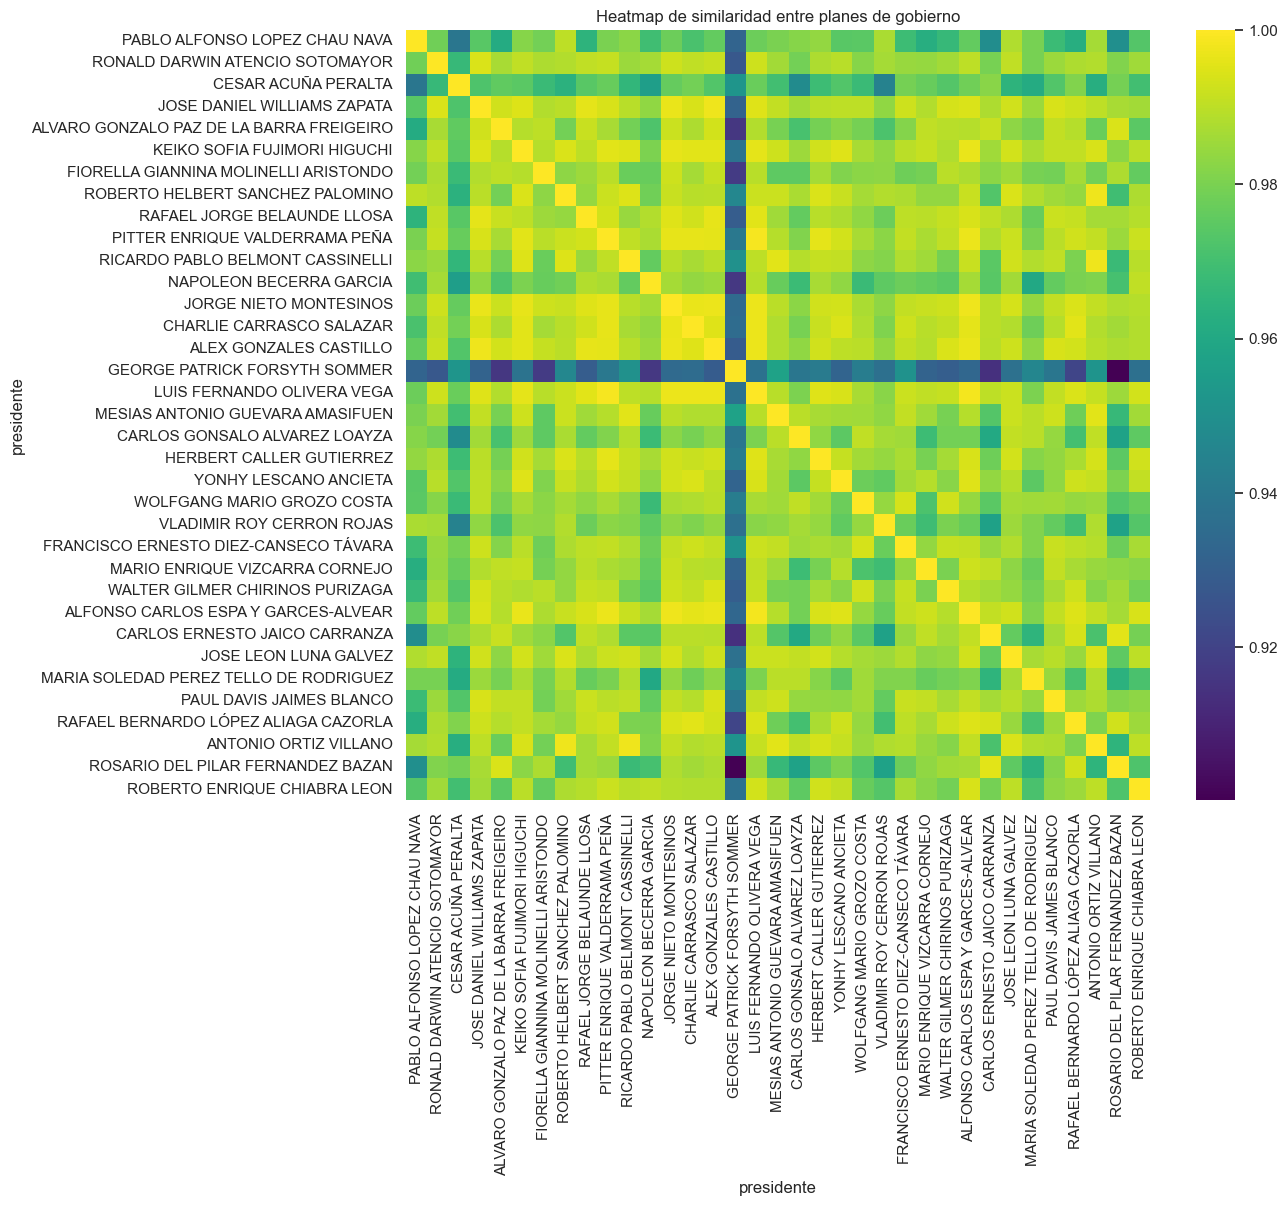

In [22]:
plt.figure(figsize=(12, 10))
sns.heatmap(sim_df, cmap="viridis")
plt.title("Heatmap de similaridad entre planes de gobierno")
plt.show()


In [44]:
# Pares de candidatos más similares
pares = []

for i in range(len(df)):
    for j in range(i + 1, len(df)):
        pares.append({
            "candidato_1": df.loc[i, "presidente"],
            "candidato_2": df.loc[j, "presidente"],
            "similaridad": sim_matrix[i, j]
        })

pares_similares = pd.DataFrame(pares).sort_values("similaridad", ascending=False)
pares_similares.head(30)


,candidato_1,candidato_2,similaridad
276,PITTER ENRIQUE VALDERRAMA PEÑA,LUIS FERNANDO OLIVERA VEGA,0.998666
433,LUIS FERNANDO OLIVERA VEGA,ALFONSO CARLOS ESPA Y GARCES-ALVEAR,0.998241
241,ROBERTO HELBERT SANCHEZ PALOMINO,ANTONIO ORTIZ VILLANO,0.997547
316,RICARDO PABLO BELMONT CASSINELLI,ANTONIO ORTIZ VILLANO,0.997422
355,JORGE NIETO MONTESINOS,ALFONSO CARLOS ESPA Y GARCES-ALVEAR,0.997355
109,JOSE DANIEL WILLIAMS ZAPATA,ALEX GONZALES CASTILLO,0.997326
343,JORGE NIETO MONTESINOS,ALEX GONZALES CASTILLO,0.997196
345,JORGE NIETO MONTESINOS,LUIS FERNANDO OLIVERA VEGA,0.997182
366,CHARLIE CARRASCO SALAZAR,LUIS FERNANDO OLIVERA VEGA,0.997137
286,PITTER ENRIQUE VALDERRAMA PEÑA,ALFONSO CARLOS ESPA Y GARCES-ALVEAR,0.997009


# 14. PCA de documentos

Visualizamos ahora los **planes completos** proyectados a 2 dimensiones.


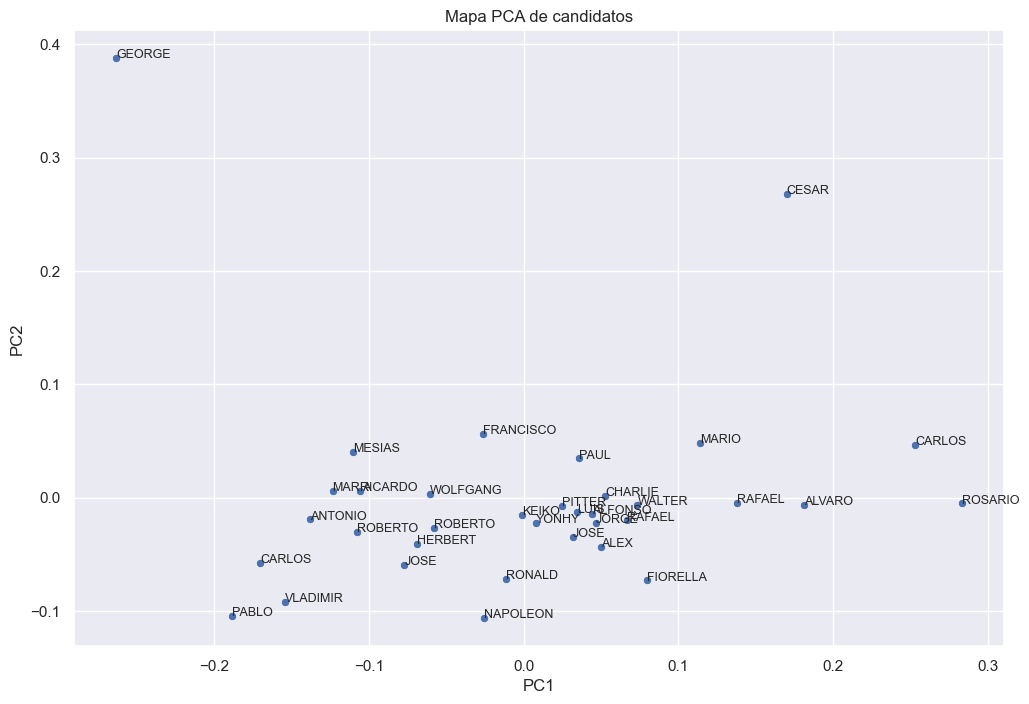

In [24]:
pca_docs = PCA(n_components=2, random_state=42)
coords_pca = pca_docs.fit_transform(doc_vectors)

plt.figure(figsize=(12, 8))
sns.scatterplot(x=coords_pca[:, 0], y=coords_pca[:, 1])

for i, name in enumerate(df["presidente"]):
    plt.text(coords_pca[i, 0], coords_pca[i, 1], name.split()[0], fontsize=9)

plt.title("Mapa PCA de candidatos")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()


# 15. t-SNE de documentos

## ¿Qué es t-SNE?

**t-SNE (t-Distributed Stochastic Neighbor Embedding)** es una técnica no lineal de reducción de dimensionalidad.

A diferencia de PCA, t-SNE intenta preservar mejor la **estructura local**, por eso suele separar mejor clusters en visualización.

### Importante

t-SNE es excelente para **exploración visual**, pero no se debe interpretar como una prueba definitiva de separación ideológica.


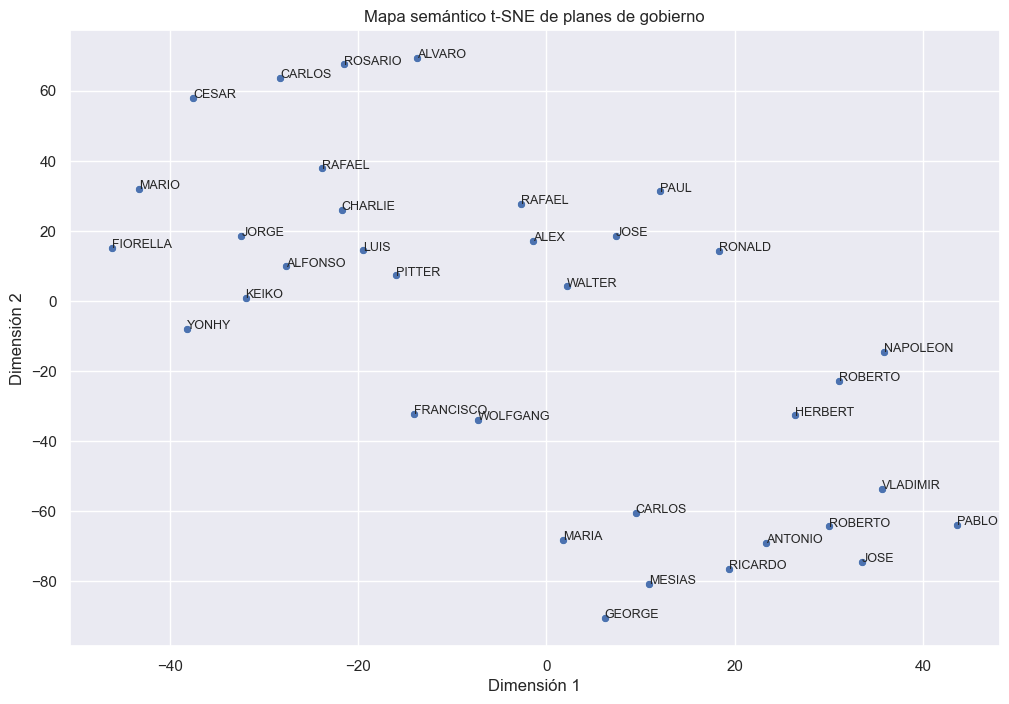

In [25]:
tsne = TSNE(
    n_components=2,
    perplexity=5,
    random_state=42,
    init="pca",
    learning_rate="auto"
)

coords_tsne = tsne.fit_transform(doc_vectors)

plt.figure(figsize=(12, 8))
sns.scatterplot(x=coords_tsne[:, 0], y=coords_tsne[:, 1])

for i, name in enumerate(df["presidente"]):
    plt.text(coords_tsne[i, 0], coords_tsne[i, 1], name.split()[0], fontsize=9)

plt.title("Mapa semántico t-SNE de planes de gobierno")
plt.xlabel("Dimensión 1")
plt.ylabel("Dimensión 2")
plt.show()


# 16. Clustering con K-Means

## Definición

**K-Means** es un algoritmo de aprendizaje no supervisado que busca particionar un conjunto de datos en \(K\) clusters.

Cada cluster está representado por un **centroide**, que corresponde al promedio de los puntos pertenecientes a ese grupo.

El objetivo del algoritmo es **minimizar la variabilidad dentro de cada cluster**.



## Función objetivo

K-Means busca minimizar la **suma de distancias cuadradas dentro de los clusters (Within-Cluster Sum of Squares)**.

$$
J = \sum_{k=1}^{K} \sum_{x_i \in C_k} \lVert x_i - \mu_k \rVert^2
$$

donde:

- \(K\) = número de clusters  
- \(C_k\) = conjunto de observaciones asignadas al cluster \(k\)  
- \(x_i\) = observación \(i\) (vector de características)  
- \(\mu_k\) = centroide del cluster \(k\)  
- \(\lVert x_i - \mu_k \rVert^2\) = distancia euclidiana cuadrada entre el punto y el centroide  



## Interpretación

El algoritmo intenta que:

- los puntos dentro de un cluster estén **lo más cerca posible del centroide**
- los clusters estén **bien separados entre sí**

Mientras menor sea el valor de \(J\), mejor será el agrupamiento.



## Algoritmo paso a paso

K-Means funciona de forma iterativa:

1. Inicializar \(K\) centroides aleatoriamente.
2. Asignar cada punto al centroide más cercano.
3. Recalcular cada centroide como el promedio de los puntos del cluster.
4. Repetir pasos 2 y 3 hasta convergencia.



## Interpretación en este proyecto

En nuestro caso:

- Cada \(x_i\) es un **plan de gobierno representado como embedding vectorial**.
- El algoritmo agrupa candidatos según **similitud semántica en sus discursos políticos**.

In [26]:
# Método del codo (opcional)
inertias = []

for k in range(2, 9):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(doc_vectors)
    inertias.append({"k": k, "inertia": km.inertia_})

inertias_df = pd.DataFrame(inertias)
inertias_df


,k,inertia
0,2,1.068773
1,3,0.876946
2,4,0.720382
3,5,0.643462
4,6,0.575521
5,7,0.532125
6,8,0.478579


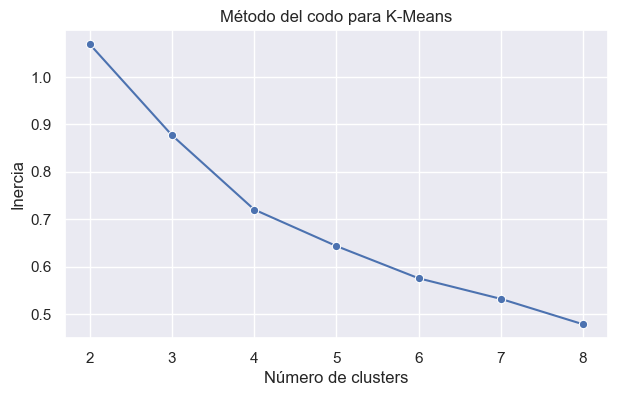

In [27]:
plt.figure(figsize=(7, 4))
sns.lineplot(data=inertias_df, x="k", y="inertia", marker="o")
plt.title("Método del codo para K-Means")
plt.xlabel("Número de clusters")
plt.ylabel("Inercia")
plt.show()


In [28]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df["cluster"] = kmeans.fit_predict(doc_vectors)

df[["presidente", "cluster"]].head()


,presidente,cluster
0,PABLO ALFONSO LOPEZ CHAU NAVA,1
1,RONALD DARWIN ATENCIO SOTOMAYOR,2
2,CESAR ACUÑA PERALTA,0
3,JOSE DANIEL WILLIAMS ZAPATA,2
4,ALVARO GONZALO PAZ DE LA BARRA FREIGEIRO,0


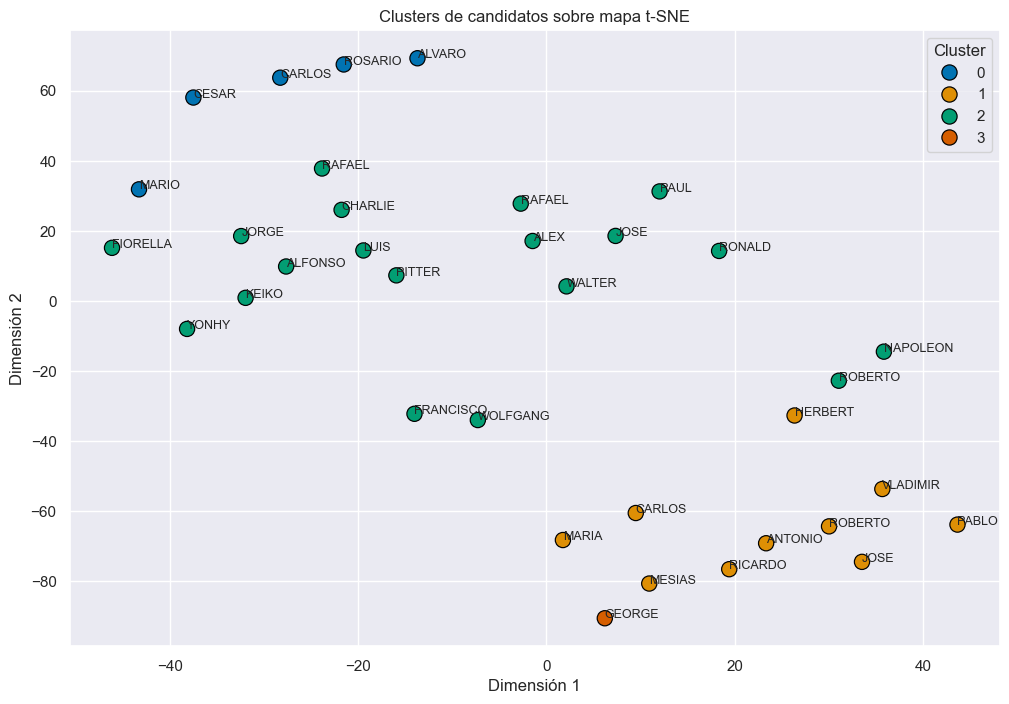

In [29]:
plt.figure(figsize=(12, 8))

sns.scatterplot(
    x=coords_tsne[:, 0],
    y=coords_tsne[:, 1],
    hue=df["cluster"],
    palette="colorblind",
    s=120,
    edgecolor="black"
)

for i, name in enumerate(df["presidente"]):
    plt.text(
        coords_tsne[i, 0],
        coords_tsne[i, 1],
        name.split()[0],
        fontsize=9
    )

plt.title("Clusters de candidatos sobre mapa t-SNE")
plt.xlabel("Dimensión 1")
plt.ylabel("Dimensión 2")

plt.legend(title="Cluster")

plt.show()


# 17. Topic Modeling con LDA

## ¿Qué es Topic Modeling?

El **Topic Modeling** es un conjunto de técnicas utilizadas para descubrir **temas latentes** dentro de una colección de documentos.

La idea es identificar **grupos de palabras que tienden a aparecer juntas**, lo que permite inferir los temas principales del corpus.

Por ejemplo, un tema podría contener palabras como:

salud, hospital, médico, atención

lo que podría interpretarse como **política de salud pública**.



# Latent Dirichlet Allocation (LDA)

**Latent Dirichlet Allocation (LDA)** es uno de los algoritmos más utilizados para Topic Modeling.

El modelo asume que:

- cada documento es una **mezcla de temas**
- cada tema es una **distribución de palabras**

Matemáticamente:

Documento → mezcla de tópicos  
Tópico → distribución de palabras



# Paso 1: Stopwords en español


In [30]:
import nltk
from nltk.corpus import stopwords

nltk.download("stopwords")

spanish_stopwords = stopwords.words("spanish")

extra_stopwords = [
    "peru","perú","pais","país",
    "gobierno","plan","nacional",
    "propuesta","programa","sector",
    "publico","publica"
]

stopwords_final = spanish_stopwords + extra_stopwords


[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/josefrodriguez/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [31]:
from sklearn.feature_extraction.text import CountVectorizer

count_vectorizer = CountVectorizer(
    
    stop_words=stopwords_final,
    
    max_df=0.9,      # elimina palabras muy comunes
    min_df=2,        # elimina palabras muy raras
    
    ngram_range=(1,2),   # unigramas + bigramas
    
    max_features=3000
)

X_count = count_vectorizer.fit_transform(df["texto_clean"])

print("Shape matriz documento-palabra:", X_count.shape)

Shape matriz documento-palabra: (35, 3000)


In [32]:
from sklearn.decomposition import LatentDirichletAllocation

lda = LatentDirichletAllocation(
    
    n_components=5,      # número de tópicos
    random_state=42,
    
    learning_method="batch"
)

X_topics = lda.fit_transform(X_count)


## Interpretación de tópicos

Los tópicos no vienen con nombre automático; el analista debe interpretarlos a partir de las palabras dominantes.

Por ejemplo, un tópico con palabras como:

- salud
- hospital
- médico
- atención

probablemente se interprete como **tema de salud pública**.


In [33]:
import pandas as pd

def mostrar_top_palabras_lda(model, feature_names, n_top_words=10):
    
    topics = []
    
    for topic_idx, topic in enumerate(model.components_):
        
        top_features_idx = topic.argsort()[-n_top_words:][::-1]
        
        top_words = [feature_names[i] for i in top_features_idx]
        
        topics.append({
            "topic": f"Topic {topic_idx}",
            "top_words": ", ".join(top_words)
        })
        
    return pd.DataFrame(topics)

feature_names = count_vectorizer.get_feature_names_out()

topics_df = mostrar_top_palabras_lda(lda, feature_names, n_top_words=12)

topics_df


,topic,top_words
0,Topic 0,"actividad, estratégica, seguridad, regionales, porcentaje, ley, pobreza, gobiernos, millones, peruanos, público, derechos"
1,Topic 1,"porcentaje, estudiantes, niveles, vida, altos, urbana, base, línea, calidad, cultural, público, tasa"
2,Topic 2,"reducir, número, porcentaje, pública, tasa, inversión, participación, incrementar, seguridad, empleo, pbi, fortalecer"
3,Topic 3,"meta, porcentaje, indicador, gestión, número, cantidad, sostenible, infraestructura, calidad, productiva, crecimiento, brechas"
4,Topic 4,"porcentaje, menos, número, infraestructura, reducir, agua, millones, años, zonas, fortalecer, educación, gestión"


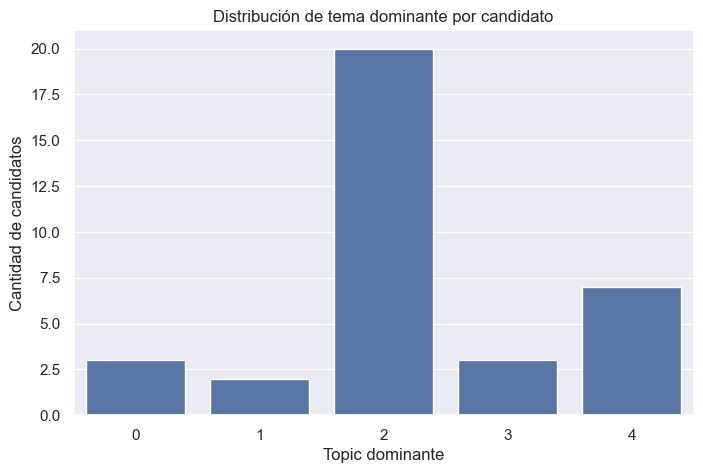

In [34]:
df["topic_dominante"] = X_topics.argmax(axis=1)

plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="topic_dominante")
plt.title("Distribución de tema dominante por candidato")
plt.xlabel("Topic dominante")
plt.ylabel("Cantidad de candidatos")
plt.show()


In [35]:
topic_cols = [f"topic_{i}" for i in range(X_topics.shape[1])]

topics_proportions = pd.DataFrame(X_topics, columns=topic_cols)

df_topics = pd.concat([df[["presidente"]], topics_proportions], axis=1)

df_topics.head()

,presidente,topic_0,topic_1,topic_2,topic_3,topic_4
0,PABLO ALFONSO LOPEZ CHAU NAVA,0.000025,0.000025,0.000026,0.999899,0.000025
1,RONALD DARWIN ATENCIO SOTOMAYOR,0.999539,0.000114,0.000116,0.000115,0.000115
2,CESAR ACUÑA PERALTA,0.000474,0.000475,0.594023,0.303515,0.101513
3,JOSE DANIEL WILLIAMS ZAPATA,0.000259,0.000256,0.994909,0.000258,0.004319
4,ALVARO GONZALO PAZ DE LA BARRA FREIGEIRO,0.000392,0.000394,0.998422,0.000396,0.000396


In [45]:
df["topic_dominante"] = X_topics.argmax(axis=1)

df[["presidente","topic_dominante"]].head(32)

,presidente,topic_dominante
0,PABLO ALFONSO LOPEZ CHAU NAVA,3
1,RONALD DARWIN ATENCIO SOTOMAYOR,0
2,CESAR ACUÑA PERALTA,2
3,JOSE DANIEL WILLIAMS ZAPATA,2
4,ALVARO GONZALO PAZ DE LA BARRA FREIGEIRO,2
5,KEIKO SOFIA FUJIMORI HIGUCHI,4
6,FIORELLA GIANNINA MOLINELLI ARISTONDO,2
7,ROBERTO HELBERT SANCHEZ PALOMINO,2
8,RAFAEL JORGE BELAUNDE LLOSA,1
9,PITTER ENRIQUE VALDERRAMA PEÑA,2


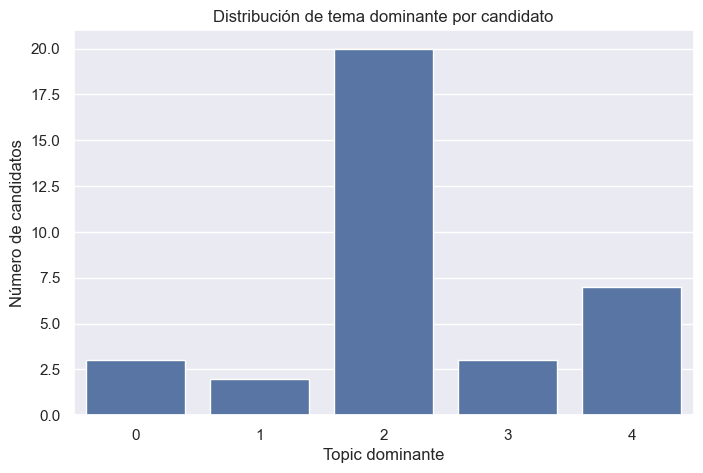

In [37]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

sns.countplot(data=df, x="topic_dominante")

plt.title("Distribución de tema dominante por candidato")
plt.xlabel("Topic dominante")
plt.ylabel("Número de candidatos")

plt.show()

# 18. WordCloud por candidato

Podemos generar una WordCloud para un candidato específico.

Esto sirve para análisis exploratorio o presentaciones en clase.


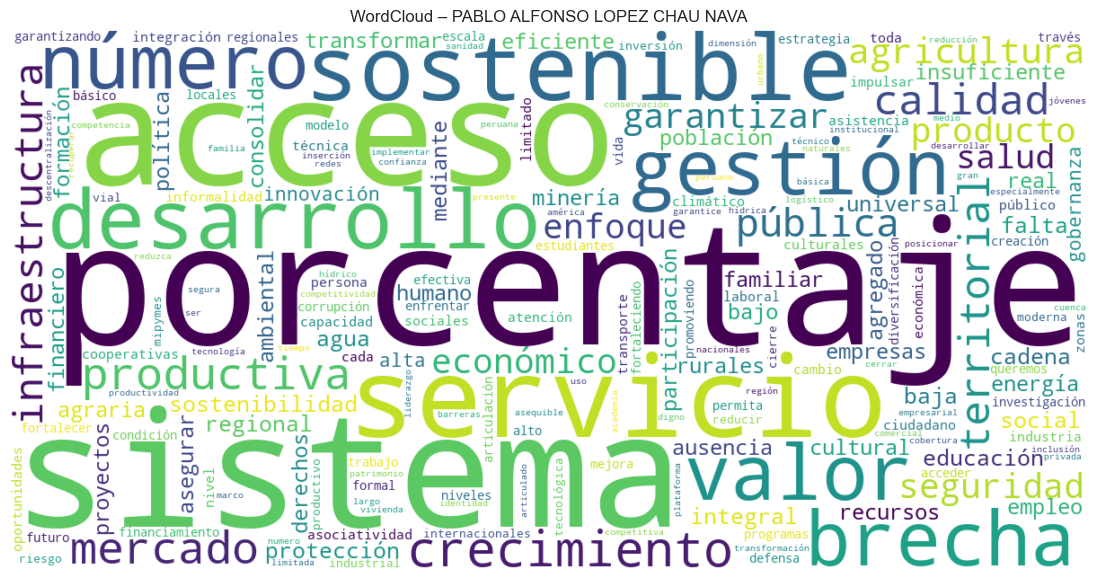

In [38]:
candidato_idx = 0
candidato_nombre = df.loc[candidato_idx, "presidente"]

texto_candidato = " ".join(df.loc[candidato_idx, "tokens"])

wc_candidato = WordCloud(
    width=1200,
    height=600,
    background_color="white",
    stopwords=set(stopwords_final),
    collocations=False
).generate(texto_candidato)

plt.figure(figsize=(14,7))
plt.imshow(wc_candidato, interpolation="bilinear")
plt.axis("off")

plt.title(f"WordCloud – {candidato_nombre}")

plt.show()


# 19. Comparación conceptual: TF-IDF vs Word2Vec

## TF-IDF

**Ventajas**
- simple
- interpretable
- muy útil para clasificación y ranking
- identifica términos distintivos

**Limitaciones**
- no captura contexto semántico profundo
- genera vectores dispersos
- no entiende que palabras parecidas pueden tener significado cercano

## Word2Vec

**Ventajas**
- captura similitud semántica
- produce vectores densos
- permite analogías y proximidad semántica

**Limitaciones**
- requiere suficiente texto
- un promedio de embeddings puede perder información
- una palabra tiene un solo vector, sin contexto dinámico

## Idea clave

- Usa **TF-IDF** cuando quieres resaltar términos importantes
- Usa **Word2Vec** cuando quieres capturar relaciones semánticas


# 20. Limitaciones del enfoque

Es importante enseñar también las limitaciones del pipeline:

1. La limpieza puede eliminar información útil.
2. No estamos haciendo lematización.
3. Word2Vec promedio es una representación simple de documentos.
4. t-SNE es exploratorio, no concluyente.
5. LDA depende mucho de preprocesamiento y número de tópicos.
6. La interpretación política requiere criterio humano; el modelo no reemplaza análisis sustantivo.


# 21. Conclusiones finales

En esta masterclass construimos un pipeline completo de NLP aplicado a datos reales en español.

## Lo que aprendimos

- cómo limpiar texto político
- cómo explorar frecuencia léxica
- cómo representar documentos con TF-IDF
- cómo entrenar embeddings con Word2Vec
- cómo comparar candidatos por similaridad semántica
- cómo visualizar documentos con PCA y t-SNE
- cómo descubrir temas latentes con LDA
- cómo agrupar candidatos con K-Means

## Mensaje final

El verdadero valor del NLP no está solo en ejecutar modelos, sino en **transformar lenguaje humano en estructuras analizables**, conservando al mismo tiempo una interpretación crítica del contexto.


# 22. Ejercicios propuestos para el alumno

1. Construye una lista propia de stopwords en español político y repite TF-IDF.
2. Cambia `vector_size`, `window` y `min_count` en Word2Vec y compara resultados.
3. Prueba distintos valores de `n_components` en LDA.
4. Compara PCA vs t-SNE en términos de interpretación visual.
5. Repite clustering con 3, 4 y 5 clusters y analiza estabilidad.
6. Genera la WordCloud para distintos candidatos y compara vocabulario.
7. Encuentra los 5 pares de candidatos más similares y explica por qué.
